## Neural Network Hidden Layers Activation Embedding

# Setting Up the Neural Network
In the first stage, we define a simple architecture of the neural network and train it to recognize digits in the MNIST dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD
from keras import backend as K

from keras.datasets import mnist
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["animation.html"] = "jshtml"

nb_classes = 10

The dropout layers have the very specific function to drop out a random set of activations in that layer by setting them to zero in the forward pass. This allows the model to avoid overfitting but should only be used at training time, not at test time.

In [2]:
# Set dropout rate - fractions of neurons to drop
dropout = 0.5

# Build very simple neural network with 2 hidden layers
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(784,)))
model.add(Dropout(dropout))
model.add(Dense(64, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(nb_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Preparing the Data
The binary_crossentropy loss expects a one-hot-vector as input,so we apply the to_categorical function from keras.utils to convert integer labels to one-hot-vectors.

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5/6)

Let's visualize an example digit:



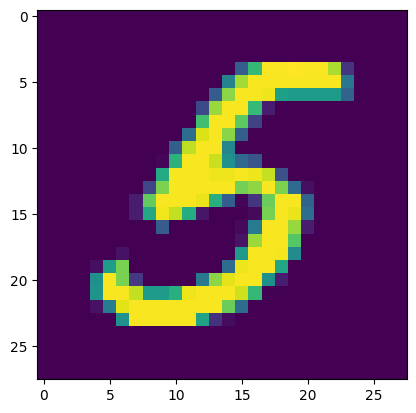

In [4]:
# Show example digit
plt.imshow(X_train[0].reshape(28, 28))

# Training the Model
When we have defined and compiled the model, it can be trained using the fit function.

We also use validation dataset to monitor validation loss and accuracy.

In [5]:
network_history = model.fit(X_train, Y_train, batch_size=128,
                           epochs=20, verbose=1, validation_data=(X_val, Y_val))

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7898 - loss: 0.6656 - val_accuracy: 0.9384 - val_loss: 0.2181
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9116 - loss: 0.3131 - val_accuracy: 0.9542 - val_loss: 0.1615
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9312 - loss: 0.2482 - val_accuracy: 0.9598 - val_loss: 0.1366
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9423 - loss: 0.2066 - val_accuracy: 0.9642 - val_loss: 0.1184
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9501 - loss: 0.1837 - val_accuracy: 0.9676 - val_loss: 0.1134
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9528 - loss: 0.1692 - val_accuracy: 0.9687 - val_loss: 0.1098
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9575 - loss: 0.1567 - val_accuracy: 0.9712 - val_loss: 0.0993
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9601 - loss: 0.1421 - val_accuracy: 0

We can visualize the training history:

In [6]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()


The fit function returns a keras.callbacks.History object which contains the entire history of training/validation loss, accuracy and other metrics for each epoch. 

We can therefore plot the behavior of loss and accuracy during the training phase.



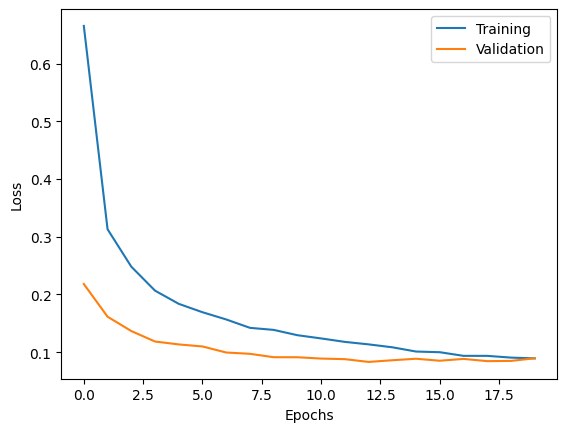

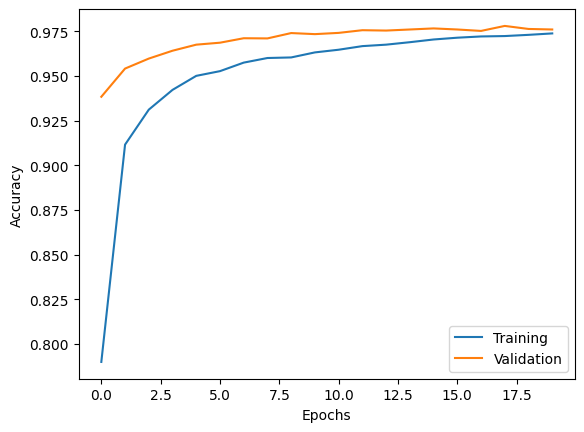

In [7]:
plot_history(network_history)


## Extracting Hidden Layer Activations
Keras Model has the summary function that prints data about model architecture



In [8]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

We are interested in downloading the activation of hidden layers, because the dropout layers are between them, we need to properly select the index of the three dense layers.

In [11]:
# get_layer_output = K.function([model.layers[0].input, model.layers[0].input, model.layers[0].input],
#                               [model.layers[0].output, model.layers[2].output, model.layers[4].output])

# layer1_output, layer2_output, layer3_output = get_layer_output([X_train])

# train_ids = [np.arange(len(Y_train))[Y_train[:,i] == 1] for i in range(10)]

from tensorflow.keras.models import Model

extractor = Model(
    inputs=model.inputs, 
    outputs=[
        model.layers[0].output, 
        model.layers[2].output, 
        model.layers[4].output
    ]
)
outputs = extractor.predict(X_train)
layer1_output, layer2_output, layer3_output = outputs[0], outputs[1], outputs[2]

train_ids = [np.arange(len(Y_train))[Y_train[:,i] == 1] for i in range(10)]

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


### Visualizing Network Activations
The 2 visualizations below show how neuron activations work:

1. First animation shows what an example digit (number 5) looks like and what activations of neurons look like in hidden layers of the neural network.

2. Second animation checks the similarity in behavior for frames showing the same digit by looking at the ensemble properties. In this case, ensemble properties refers to how the neurons behave on average for a large number of frames showing the same digit.

After summing up the responses of as few as 20-30 frames, the pattern in the second hidden layer is almost static. After combining about 70-80 frames, the pattern in the first hidden layer also appears static. This supports the idea that only a subset of all neurons is involved in the recognition of individual digits.

This observation is important when we think about using neural networks for data visualization. We can clearly see that the activations generated by examples belonging to the same class are less chaotic than the examples themselves; therefore, their visualization should give a more clustered structure.

# Exercises

## Exercise 1: MNIST Visualization Using Hidden Layer Activations
In this exercise, you will explore how the activations of hidden layers in a neural network can be used for data visualization and classification.

### Task Description
1. Project the MNIST training data into a 2-dimensional space using different dimensionality reduction techniques:
2. t-SNE
3. TriMAP
4. PaCMAP
5. UMAP

6. Use layer1_output and layer2_output to project the first and second hidden layers of the neural network into a 2-dimensional space. Apply the same dimensionality reduction methods as in step 1.

7. Visualize both the training and test data projections.

8. Use the 2-dimensional projections for classification:

9. Use embeddings learned on raw training data (and also on hidden activations of training data) to transform test data (and hidden activations of test data) into 2-dimensional space.
10. Implement the k-nearest neighbors algorithm to classify transformed points from the test set, using points from the training set as neighbors with known class assignments.
11. Since t-SNE is a non-linear, non-parametric embedding, you can't use it to transform new points into the existing embedded space. Use only UMAP, which has both fit_transform (learn manifold) and transform (project new data to existing manifold) methods.
12. Try with several values of n_neighbors, e.g., [3, 5, 10].

13. Estimate the classification accuracy using this approach:

14. Compare results for all three inputs (raw data, 1st hidden layer, 2nd hidden layer)
15. Compare results for different values of n_neighbors

### Code Template
Here's a template to help you get started:

In [ ]:
# To get hidden activations of test data use:
test_layer1_output, test_layer2_output, test_layer3_output = get_layer_output([X_test])

# To convert from one-hot encoding back to class labels:
# Use np.argmax(to_categorical(x, k), axis=1) or K.argmax

Step 1: Raw Data Embeddings Visualization


In [ ]:
# Import necessary libraries
from sklearn.manifold import TSNE
import umap
# Import other visualization techniques you need

# Apply t-SNE to raw training data
tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

# Apply UMAP to raw training data
umap_model = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umap_model.fit_transform(X_train)

# Visualize the embeddings
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=np.argmax(Y_train, axis=1), cmap='tab10', s=1)
plt.title('t-SNE: Raw Data')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=np.argmax(Y_train, axis=1), cmap='tab10', s=1)
plt.title('UMAP: Raw Data')
plt.colorbar()
plt.tight_layout()
plt.show()

# Apply UMAP transform to test data
X_test_umap = umap_model.transform(X_test)

# Visualize test data projection
plt.figure(figsize=(6, 5))
plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=np.argmax(Y_test, axis=1), cmap='tab10', s=1)
plt.title('UMAP: Raw Test Data')
plt.colorbar()
plt.show()

Step 2: Hidden Layer 1 Embeddings Visualization


In [ ]:
# Apply the same techniques to the first hidden layer activations


Step 3: Hidden Layer 2 Embeddings Visualization


In [ ]:
# Apply the same techniques to the second hidden layer activations


Step 4: Classification and Accuracy Calculation


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define a function to evaluate KNN on different embeddings
def evaluate_knn(X_train_embedded, X_test_embedded, y_train, y_test, n_neighbors_list):
    results = []
    for n_neighbors in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train_embedded, y_train)
        y_pred = knn.predict(X_test_embedded)
        accuracy = accuracy_score(y_test, y_pred)
        results.append((n_neighbors, accuracy))
        print(f"n_neighbors={n_neighbors}, Accuracy: {accuracy:.4f}")
    return results

# Convert Y_train and Y_test to class labels
y_train = np.argmax(Y_train, axis=1)
y_test = np.argmax(Y_test, axis=1)

# Test KNN with different numbers of neighbors
n_neighbors_list = [3, 5, 10]

print("Raw Data UMAP Embeddings:")
raw_results = evaluate_knn(X_train_umap, X_test_umap, y_train, y_test, n_neighbors_list)

# Repeat for hidden layer 1 and hidden layer 2 embeddings

### Expected Outcomes
1. You should observe that the visualization of hidden layer activations shows better clustering compared to raw data visualization.
2. The second hidden layer activations should generally show clearer class separation than the first hidden layer.
3. Classification accuracy should generally improve when using hidden layer activations compared to raw data, with the later layers typically providing better performance.
4. The choice of n_neighbors will impact performance, with the optimal value possibly differing between raw data and hidden layer embeddings.

# Exercise 2: Fashion-MNIST Visualization
In this exercise, you will repeat the procedures and visualizations from Exercise 1, but now using the Fashion-MNIST dataset (or any other dataset of your choice).

### Task Description
The Fashion-MNIST dataset is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes:

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

### Steps
1. Load and preprocess the Fashion-MNIST dataset.
2. Create and train a neural network similar to the one used for MNIST.
3. Extract the hidden layer activations.
4. Apply dimensionality reduction techniques (t-SNE, TriMAP, PaCMAP, UMAP) to visualize:
5. Raw data
6. First hidden layer activations
7. Second hidden layer activations
8. Use UMAP embeddings for classification with KNN.
9. Compare the results with those obtained for the MNIST dataset.

### Code Template

In [ ]:
# Load the Fashion-MNIST dataset
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Preprocess data
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize data
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = np_utils.to_categorical(y_train, 10)
Y_test = np_utils.to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5/6)

# Build and train the neural network
# ...

# Extract hidden layer activations
# ...

# Apply visualization techniques
# ...

# Perform classification using KNN
# ...

### Expected Outcomes
1. Compare the visualization results between MNIST and Fashion-MNIST:
2. Are class boundaries clearer in one dataset versus the other?
3. Do hidden layer activations provide better separation in Fashion-MNIST compared to raw data?
4. Which classes in Fashion-MNIST are most easily confused in the visualizations?

5. Compare classification performance:

6. How does accuracy on Fashion-MNIST compare to MNIST?
7. Does using hidden layer activations provide a similar boost in performance for Fashion-MNIST as it did for MNIST?
8. Which classes benefit most from using hidden layer activations for classification?

### Discussion Questions
1. How does the neural network's representation of fashion items differ from its representation of digits?
2. What might explain any differences in visualization clarity or classification performance between the two datasets?
3. Which dimensionality reduction technique works best for Fashion-MNIST, and is this the same as what worked best for MNIST?
4. How might you modify the neural network architecture to improve visualization or classification for Fashion-MNIST specifically?